# Query Transformation Optimization

Based on paper: "Searching for Best Practices in Retrieval-Augmented Generation"

This notebook optimizes query transformation techniques using **optimal configuration**:
- Chunking: Semantic-Level, 192 tokens (frozen)
- Retriever: Dense MMR, k=8 (frozen)

Tests 4 query transformation methods to enhance retrieval quality:
1. **Baseline:** Original query (no transformation)
2. **HyDE:** Generate hypothetical documents from query
3. **Query Rewriting:** Refine query for better matching
4. **Query Decomposition:** Break into sub-queries

Goal: Identify if query transformation improves context relevance with Dense MMR

## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk rank-bm25


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Import Libraries

In [2]:
import os
import json
import re
import numpy as np
import pandas as pd
import tiktoken
import shutil
import tempfile
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from datasets import load_dataset
from nltk.tokenize import sent_tokenize
import nltk
from typing import Callable, List

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

nltk.download('punkt_tab', quiet=True)

load_dotenv()
openrouter_token = os.environ.get('OPENROUTER_TOKEN')

print("✓ All imports successful")

/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset & Setup Models

In [ ]:
import sys, os


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT

print("Loading dataset...")
DATASET_NAME = "delucionqa"  # feeds both load_rag_bench_data() and vector store naming below
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=50)
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

# Setup models
embedding_model = get_embedding_model(openrouter_token)

llm = get_generation_llm(openrouter_token)

query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)

llama_judge = get_judge_llm(openrouter_token)

prompt = RAG_GENERATION_PROMPT

print("✓ Models configured")


## Step 4: Semantic-Level Chunking (192t - Frozen)

In [ ]:
from ragbench_lib.chunking import count_tokens, get_sentences, create_semantic_chunks

print("Preparing semantic chunks (192t)...")
documents = create_semantic_chunks(docs_df, target_tokens=192)
print(f"✓ Created {len(documents)} semantic chunks")


## Step 5: Dense MMR Retriever (Frozen)

In [ ]:
from ragbench_lib.retrievers import DenseMMRRetriever

print("Creating Dense MMR retriever...")
retriever = DenseMMRRetriever(documents, embedding_model, k=8, dataset_name=DATASET_NAME)
print("✓ Dense MMR retriever ready (k=8, λ=0.5)")


## Step 6: TRACe Evaluation Metrics

In [ ]:
from ragbench_lib.chunking import get_sentences
from ragbench_lib.trace_eval import (
    format_documents_with_keys,
    annotate_response_for_metrics as _annotate_response_for_metrics,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)


def annotate_response_for_metrics(documents, question, response):
    """Annotate a response using this notebook's judge LLM (llama_judge)."""
    return _annotate_response_for_metrics(llama_judge, documents, question, response)


print("✓ TRACe metric functions ready (ragbench_lib.trace_eval)")

## Step 7: Query Transformation Methods

In [7]:
def apply_hyde(query, llm):
    """HyDE: Generate hypothetical document that would answer the query"""
    prompt = f"""Write a comprehensive document that would answer this question:
    
'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
    
    try:
        response = llm.invoke(prompt)
        return response.content.strip()
    except Exception as e:
        print(f"      [DEBUG] HyDE error: {str(e)[:50]}")
        return query

def apply_query_rewriting(query, llm):
    """Query Rewriting: Refine query for better matching"""
    prompt = f"""Rewrite this query to be more specific, clear, and optimized for document retrieval.
Add relevant context and make implicit parts explicit.

Original query: '{query}'

Rewritten query:"""
    
    try:
        response = llm.invoke(prompt)
        return response.content.strip()
    except Exception as e:
        print(f"      [DEBUG] Query Rewriting error: {str(e)[:50]}")
        return query

def apply_query_decomposition(query, llm):
    """Query Decomposition: Break complex query into sub-queries"""
    prompt = f"""Break this complex query into 2-3 simpler, more specific sub-queries that together answer the original question.
Return the sub-queries as a list, separated by newlines.

Original query: '{query}'

Sub-queries:"""
    
    try:
        response = llm.invoke(prompt)
        content = response.content.strip()
        queries = [q.strip() for q in content.split('\n') if q.strip()]
        return ' '.join(queries[:3])  # Combine top 3
    except Exception as e:
        print(f"      [DEBUG] Query Decomposition error: {str(e)[:50]}")
        return query

print("✓ Query transformation methods ready")

✓ Query transformation methods ready


## Step 8: Experiment Runner

In [8]:
def run_query_transformation_experiment(transform_name, transform_func, docs_df, retriever, llm, prompt, num_samples=5):
    """Run experiment for a specific query transformation"""
    print(f"  {transform_name:35s}...", end=" ", flush=True)
    
    try:
        def format_docs(docs):
            return "\n\n".join(doc.page_content for doc in docs)
        
        rag_chain = ({"context": lambda x: format_docs(retriever.retrieve(x)), "question": lambda x: x} 
                     | prompt | llm | StrOutputParser())
        
        unique_samples = docs_df.drop_duplicates(subset=['row_id']).head(num_samples).reset_index(drop=True)
        results = []
        
        for i, row in unique_samples.iterrows():
            try:
                original_question = row['question']
                
                # Apply transformation
                if transform_func is not None:
                    transformed_question = transform_func(original_question, query_llm)
                else:
                    transformed_question = original_question
                
                # Get response using transformed query
                my_response = rag_chain.invoke(transformed_question)
                
                # Retrieve using transformed query but evaluate against original
                retrieved_docs = retriever.retrieve(transformed_question)
                retrieved_texts = [doc.page_content for doc in retrieved_docs]
                
                annotation = annotate_response_for_metrics(retrieved_texts, original_question, my_response)
                
                if annotation['success']:
                    results.append({
                        'context_relevance': compute_context_relevance(retrieved_texts, annotation),
                        'utilization': compute_utilization(retrieved_texts, annotation),
                        'completeness': compute_completeness(annotation),
                        'adherence': compute_adherence(annotation),
                    })
            except Exception as e:
                pass
        
        if results:
            avg_metrics = {
                'method': transform_name,
                'context_relevance': np.mean([r['context_relevance'] for r in results]),
                'utilization': np.mean([r['utilization'] for r in results]),
                'completeness': np.mean([r['completeness'] for r in results]),
                'adherence': np.mean([r['adherence'] for r in results]),
            }
            print(f"✓ (CR: {avg_metrics['context_relevance']:.4f})")
            return avg_metrics
        else:
            print("✗ No results")
            return None
    except Exception as e:
        print(f"✗ Error: {str(e)[:50]}")
        return None

print("✓ Experiment runner ready")

✓ Experiment runner ready


## Step 9: Run Query Transformation Experiments

In [9]:
print("\n" + "="*100)
print("QUERY TRANSFORMATION OPTIMIZATION")
print("Testing 4 query transformation methods with Dense MMR retriever")
print("="*100 + "\n")

transformation_results = []

# Baseline: Original query (no transformation)
result = run_query_transformation_experiment("Q0: Baseline (Original Query)", None, docs_df, retriever, llm, prompt, num_samples=5)
if result:
    transformation_results.append(result)

# Q1: HyDE
result = run_query_transformation_experiment("Q1: HyDE (Hypothetical Doc)", apply_hyde, docs_df, retriever, llm, prompt, num_samples=5)
if result:
    transformation_results.append(result)

# Q2: Query Rewriting
result = run_query_transformation_experiment("Q2: Query Rewriting", apply_query_rewriting, docs_df, retriever, llm, prompt, num_samples=5)
if result:
    transformation_results.append(result)

# Q3: Query Decomposition
result = run_query_transformation_experiment("Q3: Query Decomposition", apply_query_decomposition, docs_df, retriever, llm, prompt, num_samples=5)
if result:
    transformation_results.append(result)

print("\n" + "="*100)
print("QUERY TRANSFORMATION RANKING RESULTS")
print("="*100)

if transformation_results:
    df_results = pd.DataFrame(transformation_results)
    display(df_results)
    
    best_idx = df_results['context_relevance'].idxmax()
    best_result = df_results.iloc[best_idx]
    baseline = df_results[df_results['method'].str.contains('Baseline')].iloc[0]
    
    print("\n" + "-"*100)
    print(f"🏆 BEST METHOD: {best_result['method']}")
    print("-"*100)
    print(f"  Context Relevance:  {best_result['context_relevance']:.4f}")
    print(f"  Utilization:        {best_result['utilization']:.4f}")
    print(f"  Completeness:       {best_result['completeness']:.4f}")
    print(f"  Adherence:          {best_result['adherence']:.4f}")
    
    improvement = ((best_result['context_relevance'] - baseline['context_relevance']) / baseline['context_relevance'] * 100)
    print(f"\n  Improvement vs Baseline: {improvement:+.1f}%")
    print("-"*100)
    
    print("\nFULL RANKING:")
    df_ranked = df_results.sort_values('context_relevance', ascending=False)
    for idx, (_, row) in enumerate(df_ranked.iterrows(), 1):
        medal = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else "  "
        print(f"{medal} {idx}. {row['method']:40s} | CR: {row['context_relevance']:.4f} | Util: {row['utilization']:.4f} | Compl: {row['completeness']:.4f} | Adh: {row['adherence']:.4f}")
else:
    print("No results collected")


QUERY TRANSFORMATION OPTIMIZATION
Testing 4 query transformation methods with Dense MMR retriever

  Q0: Baseline (Original Query)      ... ✓ (CR: 0.0616)
  Q1: HyDE (Hypothetical Doc)        ... ✓ (CR: 0.0483)
  Q2: Query Rewriting                ... ✓ (CR: 0.0366)
  Q3: Query Decomposition            ... ✓ (CR: 0.0470)

QUERY TRANSFORMATION RANKING RESULTS


,method,context_relevance,utilization,completeness,adherence
0,Q0: Baseline (Original Query),0.06162,0.04208,0.67778,0.8
1,Q1: HyDE (Hypothetical Doc),0.04834,0.01112,0.24666,0.4
2,Q2: Query Rewriting,0.03660,0.02910,0.85000,1.0
3,Q3: Query Decomposition,0.04696,0.02296,0.60714,0.8



----------------------------------------------------------------------------------------------------
🏆 BEST METHOD: Q0: Baseline (Original Query)
----------------------------------------------------------------------------------------------------
  Context Relevance:  0.0616
  Utilization:        0.0421
  Completeness:       0.6778
  Adherence:          0.8000

  Improvement vs Baseline: +0.0%
----------------------------------------------------------------------------------------------------

FULL RANKING:
🥇 1. Q0: Baseline (Original Query)            | CR: 0.0616 | Util: 0.0421 | Compl: 0.6778 | Adh: 0.8000
🥈 2. Q1: HyDE (Hypothetical Doc)              | CR: 0.0483 | Util: 0.0111 | Compl: 0.2467 | Adh: 0.4000
🥉 3. Q3: Query Decomposition                  | CR: 0.0470 | Util: 0.0230 | Compl: 0.6071 | Adh: 0.8000
   4. Q2: Query Rewriting                      | CR: 0.0366 | Util: 0.0291 | Compl: 0.8500 | Adh: 1.0000


## Step 10: Visualize Results

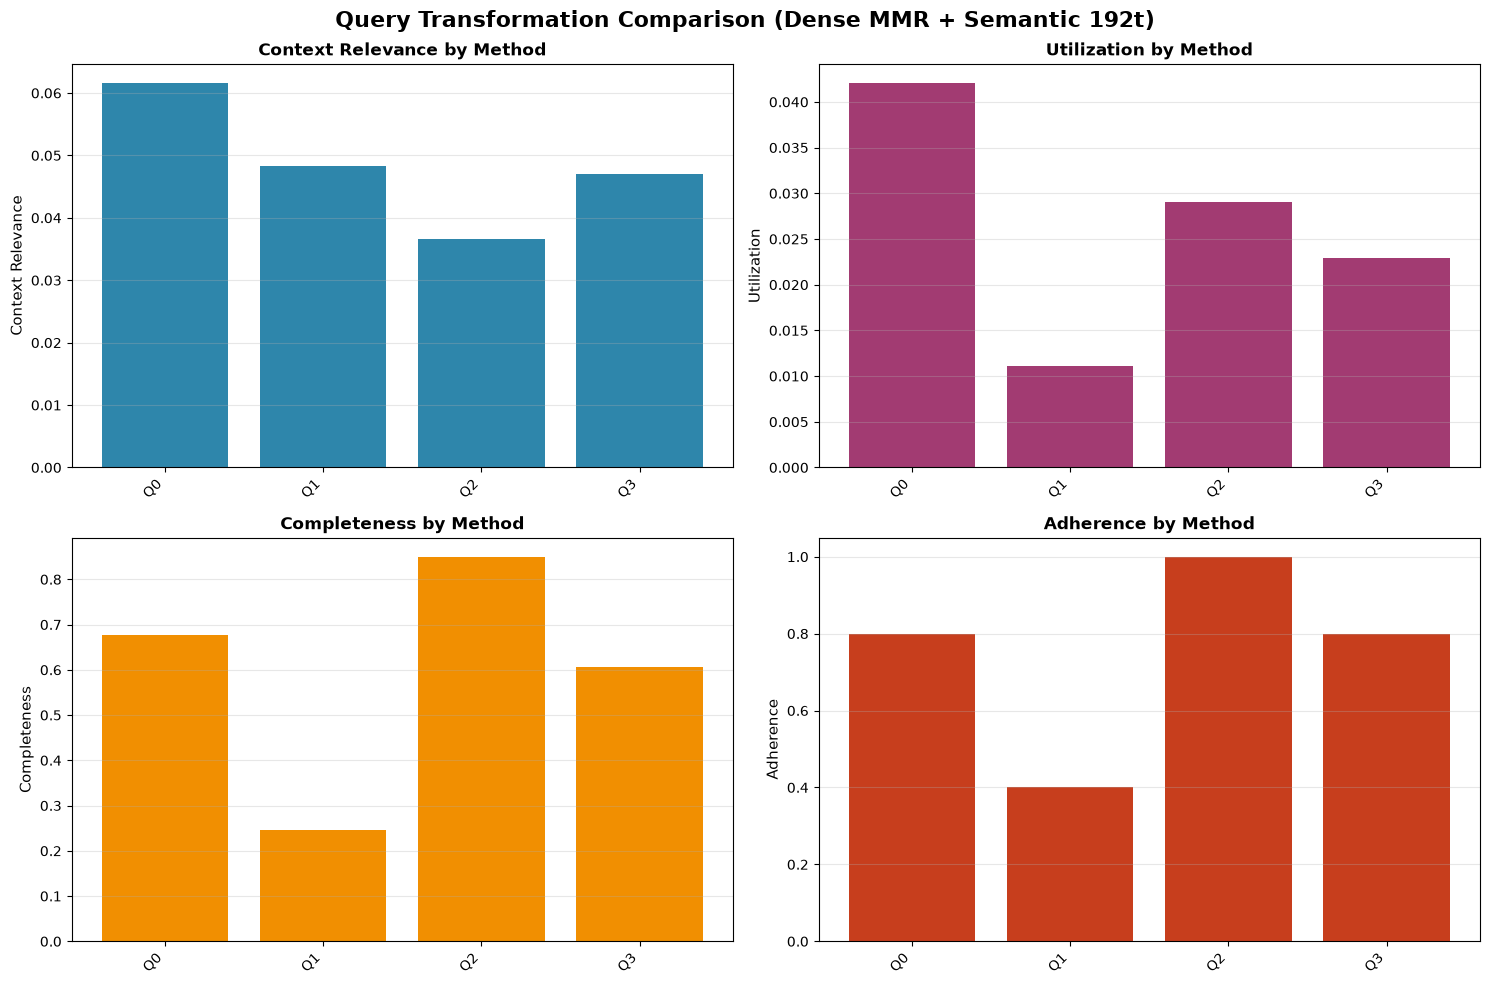


✓ Visualization complete


In [10]:
if transformation_results:
    df_results = pd.DataFrame(transformation_results)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Query Transformation Comparison (Dense MMR + Semantic 192t)', fontsize=16, fontweight='bold')
    
    x_pos = np.arange(len(df_results))
    
    # Context Relevance
    axes[0, 0].bar(x_pos, df_results['context_relevance'], color='#2E86AB')
    axes[0, 0].set_ylabel('Context Relevance', fontsize=11)
    axes[0, 0].set_title('Context Relevance by Method', fontsize=12, fontweight='bold')
    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels([m.split(':')[0] for m in df_results['method']], rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Utilization
    axes[0, 1].bar(x_pos, df_results['utilization'], color='#A23B72')
    axes[0, 1].set_ylabel('Utilization', fontsize=11)
    axes[0, 1].set_title('Utilization by Method', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels([m.split(':')[0] for m in df_results['method']], rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Completeness
    axes[1, 0].bar(x_pos, df_results['completeness'], color='#F18F01')
    axes[1, 0].set_ylabel('Completeness', fontsize=11)
    axes[1, 0].set_title('Completeness by Method', fontsize=12, fontweight='bold')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels([m.split(':')[0] for m in df_results['method']], rotation=45, ha='right')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Adherence
    axes[1, 1].bar(x_pos, df_results['adherence'], color='#C73E1D')
    axes[1, 1].set_ylabel('Adherence', fontsize=11)
    axes[1, 1].set_title('Adherence by Method', fontsize=12, fontweight='bold')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels([m.split(':')[0] for m in df_results['method']], rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete")

## Step 11: Summary & Recommendations

In [11]:
if transformation_results:
    df_results = pd.DataFrame(transformation_results).sort_values('context_relevance', ascending=False)
    baseline = df_results[df_results['method'].str.contains('Baseline')].iloc[0]
    
    print("\n" + "="*100)
    print("QUERY TRANSFORMATION SUMMARY")
    print("="*100)
    print(f"\n📊 Total Methods Tested: {len(df_results)}")
    print(f"🏆 Best Method: {df_results.iloc[0]['method']}")
    print(f"   Context Relevance: {df_results.iloc[0]['context_relevance']:.4f}")
    print(f"\n📈 Performance vs Baseline:")
    for idx, row in df_results.iterrows():
        improvement = ((row['context_relevance'] - baseline['context_relevance']) / baseline['context_relevance'] * 100)
        print(f"   {row['method']:40s}: {improvement:+6.1f}%")
    
    print(f"\n💡 Key Insights:")
    best = df_results.iloc[0]
    print(f"   - Best transformation: {best['method']}")
    print(f"   - Improvement: {((best['context_relevance'] - baseline['context_relevance']) / baseline['context_relevance'] * 100):+.1f}%")
    print(f"   - Recommended for production: {'Yes' if ((best['context_relevance'] - baseline['context_relevance']) / baseline['context_relevance'] * 100) > 5 else 'Consider as optional'}")
    print("\n" + "="*100)


QUERY TRANSFORMATION SUMMARY

📊 Total Methods Tested: 4
🏆 Best Method: Q0: Baseline (Original Query)
   Context Relevance: 0.0616

📈 Performance vs Baseline:
   Q0: Baseline (Original Query)           :   +0.0%
   Q1: HyDE (Hypothetical Doc)             :  -21.6%
   Q3: Query Decomposition                 :  -23.8%
   Q2: Query Rewriting                     :  -40.6%

💡 Key Insights:
   - Best transformation: Q0: Baseline (Original Query)
   - Improvement: +0.0%
   - Recommended for production: Consider as optional

